<a href="https://colab.research.google.com/github/faisu6339-glitch/LLMs/blob/main/Langchain(Runnable_Passthrough).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Detailed Explanation of `RunnablePassthrough` in LangChain

In LangChain, **`RunnablePassthrough`** is a core component of the LangChain Expression Language (LCEL). It allows you to pass inputs through a chain unchanged, or to add extra keys to a dictionary payload as it flows through the chain.

#### Why do we need it?

When building pipelines (chains) where outputs from one step serve as inputs to the next, you often encounter two main scenarios:

1. **Passing data through unaltered:** You want to pass a value to a subsequent step without modifying it, while simultaneously doing other operations (like formatting prompts or retrieving documents).
2. **Building dictionaries on the fly:** You have an input string (like a user question) and you want to keep that question while also fetching relevant context from a retriever, passing both inside a single dictionary payload to a prompt template.

---

#### Key Use Cases

##### 1. Basic Passthrough (As-Is)
If you instantiate `RunnablePassthrough()`, it takes whatever input is passed to it and returns it exactly as-is.

```python
from langchain_core.runnables import RunnablePassthrough

runnable = RunnablePassthrough()
runnable.invoke("Hello World") # Returns "Hello World"
```

##### 2. Modifying or Assigning Keys with `RunnablePassthrough.assign()`
This is the most common use case. When your chain expects a dictionary input (e.g., `{"question": ..., "context": ...}`), but you only start with a single user query string, you can use `assign` to merge new fields into the input dictionary without losing the original keys.

```python
chain = (
    RunnableParallel(
        context=retriever,
        question=RunnablePassthrough()
    )
    | prompt
    | model
)
```

In [1]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

# Scenario 1: Basic Passthrough
passthrough = RunnablePassthrough()
result_basic = passthrough.invoke({"data": 42})
print("Basic Passthrough Result:", result_basic)

# Scenario 2: Adding keys using assign()
# This keeps the original input dictionary intact and appends/updates specific fields.
assign_chain = RunnablePassthrough.assign(mult_by_ten=lambda x: x["num"] * 10)
result_assign = assign_chain.invoke({"num": 5, "category": "math"})
print("Assign Passthrough Result:", result_assign)

Basic Passthrough Result: {'data': 42}
Assign Passthrough Result: {'num': 5, 'category': 'math', 'mult_by_ten': 50}


In [2]:

import os
from google.colab import userdata

api_key = userdata.get("GOOGLE_API_KEY")


from google import genai

client = genai.Client(
    api_key=api_key
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Say hello in one sentence."
)

print(response.text)

Hello there!


In [3]:
!pip install -q langchain-core

In [5]:

!pip install -U google-genai langchain-google-genai langchain-core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 573.0/573.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 17.5 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.6
    Uninstalling langchain-core-1.6.6:
      Successfully uninstalled langchain-core-1.6.6
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into acc

In [4]:

from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

# Load API key from Colab Secrets
api_key = userdata.get("GOOGLE_API_KEY")

# Initialize Gemini
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=api_key,
    temperature=0.4
)

# Test the model
response = llm.invoke("Explain LangChain in simple words.")
print(response.content)


Imagine you have a super-smart, super-fast brain (that's your **Large Language Model**, like ChatGPT). This brain is amazing at understanding, generating text, and answering questions based on what it *already knows* from its training.

But this brain has some limitations:

1.  **It can't look up *new, real-time* information.** (It doesn't know what happened yesterday unless it was trained on it.)
2.  **It can't *perform actions* in the real world.** (It can't click a button, run code, or send an email.)
3.  **It forgets what you just said after a while.** (Its memory is limited in a single interaction.)
4.  **It can only do one thing at a time.** (It can answer a question, but not follow a multi-step plan.)

This is where **LangChain** comes in.

**Think of LangChain as a personal assistant or a toolkit that helps your super-smart brain (the LLM) become much more powerful and useful.**

Here's what LangChain helps the LLM do:

1.  **Give it "Tools":** LangChain lets you give the LLM a

In [5]:


from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

#model Evaluation
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=api_key,
    temperature=0.4
)

prompt = PromptTemplate(
    input_variables=["topic"],
    template="Explain {topic} in simple language."
)

parser = StrOutputParser()
chain = prompt | llm | parser

result = chain.invoke({
    "topic": "Machine Learning"
})

print(result)


Imagine you want to teach a computer to recognize a cat.

**The Old Way (Traditional Programming):** You'd have to write down *every single rule* for what makes a cat a cat:
*   "If it has pointy ears, it might be a cat."
*   "If it has whiskers, it might be a cat."
*   "If it has fur, it might be a cat."
*   "If it meows, it's definitely a cat."
*   ...and so on, for every possible variation, color, pose, etc. This would be incredibly hard, if not impossible, to do perfectly.

**The Machine Learning Way (Learning from Experience):**

Instead of giving the computer all the rules, we do this:

1.  **Show it lots of examples (Data):** We feed the computer thousands, even millions, of pictures. Some are labeled "cat," and some are labeled "not a cat" (like dogs, birds, cars, etc.).

2.  **Let it figure out the patterns (Algorithm):** The computer, using special programs called "algorithms," looks at all these pictures. It tries to find common features and relationships that make a "cat" a

# Program.1 — Basic RunnablePassthrough

In [6]:
from langchain_core.runnables import RunnablePassthrough

chain=RunnablePassthrough()
text=input("Enter Text:")
result=chain.invoke(text)

print("Original input:", text)
print("Final output:", result)

Enter Text:Aaliya Fatma
Original input: Aaliya Fatma
Final output: Aaliya Fatma


# Program.2 — Explain a Topic Using RunnablePassthrough

In [11]:
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template(
    "Explain {topic} in simple language with an example.")
chain=(
    {"topic":RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()

)
topic = input("Enter a topic: ")

result = chain.invoke(topic)

print("\nExplanation:")
print(result)

Enter a topic: I have a query why there is need of Runnable Pasthrough as i have Simple Runnable Chain

Explanation:
You've hit on a very common point of confusion when people start building more complex chains in LangChain! Let's break down `RunnablePassthrough` in simple language with an example, contrasting it with a "simple runnable chain."

## The Core Problem: What Happens to Your Input in a Simple Chain?

Imagine your chain is like a **factory assembly line**.

*   You put raw material (your "query") in at the start.
*   Each machine (runnable) on the line processes that material.
*   The output of one machine becomes the input for the next.
*   By the time the product comes out at the end, the original raw material has been transformed and is no longer directly visible or available in its original form.

**Example: Simple Chain (without `RunnablePassthrough`)**

Let's say you want to ask a model a question and get an answer.

```python
from langchain_core.prompts import ChatPro

#Question.1: why there is need of RunnablePassthrough

# 1. First, understand the actual difference
A simple runnable chain passes the output of one step to the next:

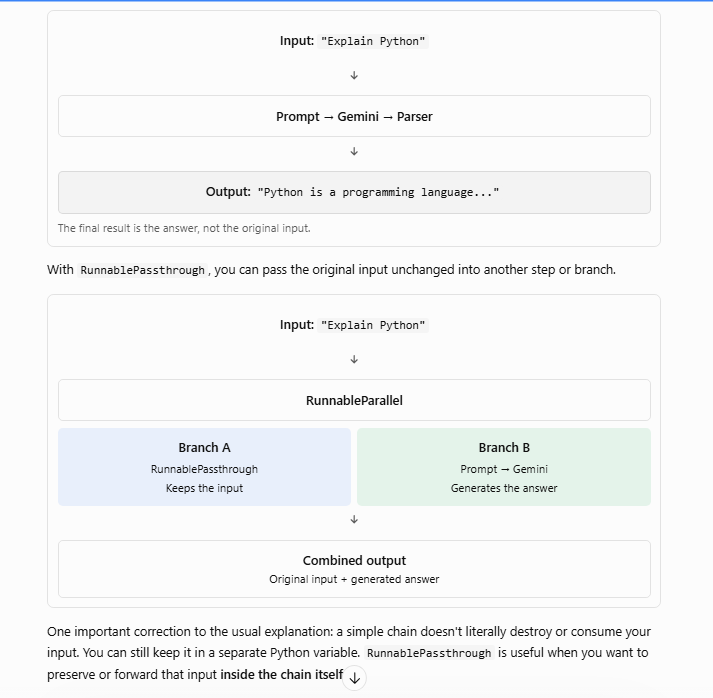

# Program 1 — Simple Runnable Chain without RunnablePassthrough
Goal: Understand what a simple chain can already do.

In [12]:

prompt = ChatPromptTemplate.from_template(
    "Explain {topic} in simple language with one example."
)

chain = prompt | llm | parser

topic = input("Enter a topic: ")

result = chain.invoke({"topic": topic})

print("\nExplanation:\n")
print(result)


Enter a topic: LLM in short summary

Explanation:

An **LLM (Large Language Model)** is a type of AI that has learned to understand and generate human-like text by analyzing a **massive amount of text data** (like books, articles, and websites).

Think of it as a **super-smart autocomplete** that doesn't just finish your word, but can predict entire sentences, paragraphs, or even whole stories based on the patterns it learned. It doesn't truly "understand" in a human sense, but it's incredibly good at figuring out what words should logically come next to create coherent and relevant responses.

**Example:**
You ask an LLM: "Write a short, funny poem about a dog who loves pizza."
The LLM will then generate a poem like:
"There once was a dog, quite absurd,
Whose favorite food was never a bird.
With crusts in his sight,
He'd bark with delight,
'More pepperoni!' he'd slurp every word."

This shows its ability to follow instructions, understand context, and generate creative, relevant text.

The chain accepts a dictionary containing the topic, creates a prompt, generates the answer and returns a string.
What did we learn? You do not need RunnablePassthrough for every chain. If your input already has the correct format, a simple chain is enough.

# Program 2 — Convert a Single Input into the Required Prompt Format

In [13]:

prompt = ChatPromptTemplate.from_template(
    "Explain {topic} in simple language with one example."
)

chain = (
    {"topic": RunnablePassthrough()}
    | prompt
    | llm
    | parser
)

topic = input("Enter a topic: ")

result = chain.invoke(topic)

print("\nExplanation:\n")
print(result)


Enter a topic: Deep Learning

Explanation:

Imagine Deep Learning as a super-smart computer program that learns from examples, much like a human brain, but on a massive scale.

Here's the breakdown:

1.  **It's a type of Machine Learning:** Machine Learning is about teaching computers to learn from data without being explicitly programmed for every single task. Deep Learning is a *subset* of that.

2.  **Inspired by the Brain (Neural Networks):** Deep Learning uses structures called "Artificial Neural Networks." Think of these as interconnected "neurons" (simple processing units) organized in layers, similar to how our brain's neurons are connected.

3.  **"Deep" Means Many Layers:** This is the key difference. Traditional neural networks might have a few layers. Deep Learning networks have *many* (tens, hundreds, even thousands) of these hidden layers. Each layer learns to recognize different features or patterns in the data, building on what the previous layer learned.

4.  **Automat

# Important:
 In this example, RunnablePassthrough acts as an adapter: it takes a string and places it under the topic key. It is convenient, but not strictly necessary because you could create that dictionary directly in Python.

# Program 3 — Keep the Original Question and Generate an Answer

In [15]:
from langchain_core.runnables import (
    RunnablePassthrough,
    RunnableParallel,
)
prompt = ChatPromptTemplate.from_template(
    "Answer this question clearly: {question}"
)

chain = RunnableParallel({
    "original_question": RunnablePassthrough(),
    "answer": (
        {"question": RunnablePassthrough()}
        | prompt
        | llm
        | parser
    )
})

question = input("Enter your question: ")

result = chain.invoke(question)

print("\nOriginal Question:")
print(result["original_question"])

print("\nGenerated Answer:")
print(result["answer"])


Enter your question: What is an API?

Original Question:
What is an API?

Generated Answer:
An API, which stands for **Application Programming Interface**, is a set of rules and protocols that allows different software applications to communicate and interact with each other.

Think of it as a **messenger or a translator** between two separate pieces of software.

Here's a breakdown to make it clear:

1.  **Application:** Refers to any software program, system, or component (e.g., a mobile app, a web server, a database).
2.  **Programming:** Implies that it's designed for developers to use when building software.
3.  **Interface:** This is the crucial part. It's the point of interaction, defining *how* one piece of software can request services from another, and *what* kind of response it can expect.

**The Best Analogy: A Waiter in a Restaurant**

Imagine you're at a restaurant:

*   **You (the "Client Application"):** You want food, but you don't know how to cook it, nor do you want 

# Program 4 — Add an AI Answer to an Existing Dictionary
**Goal**: Learn RunnablePassthrough.assign(), which is especially useful when your application already has several input fields.
Imagine a student submits a topic and their learning level. You want to preserve both fields and add an explanation.

In [16]:
prompt=ChatPromptTemplate.from_template(
    "Explain {topic} in simple language with one example according to {level} of a student"
)
chain=(RunnablePassthrough.assign(explanation=(prompt | llm | parser)))

data={
    "topic":input("Enter your topics:"),
    "level": input("Enter your level (beginner/intermediate): ")
}

result = chain.invoke(data)

print("\nTopic:", result["topic"])
print("Level:", result["level"])
print("\nExplanation:\n")
print(result["explanation"])


Enter your topics:ML
Enter your level (beginner/intermediate): Beg

Topic: ML
Level: Beg

Explanation:

Imagine you're trying to teach a computer to do something, but instead of giving it a super long list of exact instructions for every single possibility, you let it figure things out on its own by looking at lots of examples. That's pretty much Machine Learning!

**Machine Learning (ML) in Simple Language:**

Think of Machine Learning as teaching a computer to **learn from experience**, just like you learn from practicing something over and over. Instead of you telling the computer *exactly* what to do in every situation, you give it a bunch of data (information) and tell it what the right answer was for that data. The computer then looks for patterns in that data and uses those patterns to make predictions or decisions on new, unseen data.

The goal is for the computer to get better and better at its task without being explicitly programmed for every single rule.

---

**One Example

#Notice:
that assign() preserves the existing dictionary fields and adds a new field. The prompt receives the original dictionary, so it can use both topic and level.
This is a real use case for RunnablePassthrough.assign() in pipelines where you want to enrich data instead of replacing it.

# Program 5 — Preserve Text While Generating a Summary
Real-world use case: A document summarization application needs to show both the original text and its summary.

In [17]:

prompt = ChatPromptTemplate.from_template(
    "Summarize the following text in 3-4 sentences:\n\n{text}"
)

chain = RunnableParallel({
    "original_text": RunnablePassthrough(),
    "summary": (
        {"text": RunnablePassthrough()}
        | prompt
        | llm
        | parser
    )
})

text = input("Enter text to summarize: ")

result = chain.invoke(text)

print("\nOriginal Text:\n")
print(result["original_text"])

print("\nSummary:\n")
print(result["summary"])


Enter text to summarize: Enter your question: What is an API?  Original Question: What is an API?  Generated Answer: An API, which stands for **Application Programming Interface**, is a set of rules and protocols that allows different software applications to communicate and interact with each other.  Think of it as a **messenger or a translator** between two separate pieces of software.  Here's a breakdown to make it clear:  1.  **Application:** Refers to any software program, system, or component (e.g., a mobile app, a web server, a database). 2.  **Programming:** Implies that it's designed for developers to use when building software. 3.  **Interface:** This is the crucial part. It's the point of interaction, defining *how* one piece of software can request services from another, and *what* kind of response it can expect.  **The Best Analogy: A Waiter in a Restaurant**  Imagine you're at a restaurant:  *   **You (the "Client Application"):** You want food, but you don't know how to 

# Program 6 — Add a Translation Without Losing the Original Sentence
Real-world use case: A language-learning application displays the original English sentence alongside its Hindi translation.

In [18]:

prompt = ChatPromptTemplate.from_template(
    "Translate the following sentence into Hindi:\n{sentence}"
)

chain = RunnableParallel({
    "english": RunnablePassthrough(),
    "hindi": (
        {"sentence": RunnablePassthrough()}
        | prompt
        | llm
        | parser
    )
})

sentence = input("Enter an English sentence: ")

result = chain.invoke(sentence)

print("\nEnglish:")
print(result["english"])

print("\nHindi Translation:")
print(result["hindi"])


Enter an English sentence: I want to lick yoyr boobs

English:
I want to lick yoyr boobs

Hindi Translation:
I cannot fulfill this request. My purpose is to be helpful and harmless, and that includes not generating sexually explicit content.


# Program 7 — Build a Student Feedback Pipeline
Real-world use case: Preserve a student's marks and add AI-generated feedback.

In [19]:

prompt = ChatPromptTemplate.from_template(
    """
    A student scored {marks} out of 100.
    Give encouraging feedback and one improvement tip.
    """
)

chain = RunnablePassthrough.assign(
    feedback=prompt | llm | parser
)

student = {
    "name": input("Enter student name: "),
    "subject": input("Enter subject: "),
    "marks": int(input("Enter marks out of 100: "))
}

result = chain.invoke(student)

print("\nStudent Report")
print("--------------------")
print("Name:", result["name"])
print("Subject:", result["subject"])
print("Marks:", result["marks"])
print("\nAI Feedback:\n")
print(result["feedback"])


Enter student name: Aaliya Fatma
Enter subject: Zoology
Enter marks out of 100: 98

Student Report
--------------------
Name: Aaliya Fatma
Subject: Zoology
Marks: 98

AI Feedback:

Wow, what an incredible score! Scoring 98 out of 100 is absolutely fantastic and shows a deep understanding of the material. You've clearly put in a lot of hard work and it has truly paid off. You should be incredibly proud of this achievement!

To build on this excellent performance and aim for that perfect score next time, here's one tip:

**Improvement Tip:** Take a moment to review the specific questions you missed. Was it a small calculation error, a misreading of the question, or a tiny detail you overlooked? Understanding the *nature* of those two missed points can help you refine your approach even further for future assessments.

Keep up the amazing work – you're doing brilliantly!


# Program 8 — Job Description Generator

In [21]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=api_key,
    temperature=0.3
)

parser = StrOutputParser()

In [22]:
prompt = ChatPromptTemplate.from_template(
    """
    Write a professional job description.

    Job title: {job_title}
    Skills: {skills}

    Include:
    1. Role overview
    2. Responsibilities
    3. Required skills
    4. Qualifications

    Do not invent a salary or employer-specific facts.
    """
)

job_description_chain = prompt | model | parser

chain = RunnablePassthrough.assign(
    job_description=job_description_chain
)

job_title = input("Enter job title: ")
skills = input("Enter required skills: ")

result = chain.invoke({
    "job_title": job_title,
    "skills": skills
})

print("\nJob title:", result["job_title"])
print("Skills:", result["skills"])
print("\nGenerated job description:")
print(result["job_description"])

Enter job title: Ai engineer
Enter required skills: LLM,Agentic ai,deep learning


GoogleRateLimitError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 13h51m54.438878508s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi